In [1]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
import sys
# mac_home_module_path = '/Users/martinploschner/OneDrive - The University of Queensland/Coding/python_scripts/MODULES/'
# sys.path.insert(1, mac_home_module_path)
win_home_module_path = r'C:\\LAB\\Coding\\Python\\MODULES'
sys.path.insert(1, win_home_module_path)

from scipy.interpolate import UnivariateSpline
from scipy import interpolate
import pickle
import os

[Text(0.5, 0, 'gray level'), Text(0, 0.5, 'power [dBm]')]

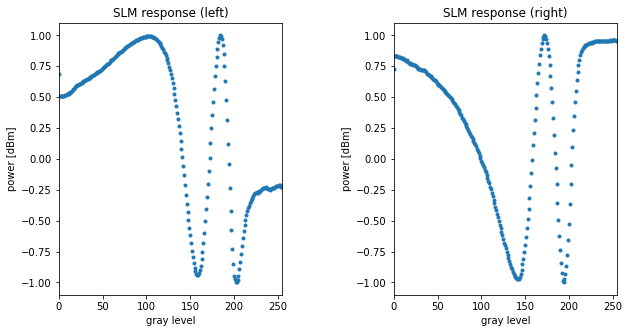

In [46]:
cwd = os.getcwd()
PIK1 = os.path.join(cwd,'results','2021_04_15_15_57_49_Meadowlark_002_1300nm_left_side_piston_WITH_REF.pkl')
PIK2 = os.path.join(cwd,'results','2021_04_15_15_54_24_Meadowlark_002_1300nm_right_side_piston_WITH_REF.pkl')

# Mesured in dBm, processing should be in W. Use 10^[(power in dBm)/(10 dBm)] to convert

with open(PIK1, "rb") as f:
    PIK1_data = pickle.load(f)

with open(PIK2, "rb") as f:
    PIK2_data = pickle.load(f)
    
l1 = np.asarray(PIK1_data['level'])
p1 = np.asarray(PIK1_data['measured_PH'])
p1[-1] = p1[-2] # The last measured point is really weird and not really used later on, substituing with closest value that makes sense
p1 = 10**(p1/10)
p1_offset = (p1.max() - p1.min())/2 + p1.min()
p1 = p1 - p1_offset
p1 = -p1/np.abs(p1).max()


l2 = np.asarray(PIK2_data['level'])
p2 = np.asarray(PIK2_data['measured_PH'])
p2[-1] = p2[-2] # The last measured point is really weird and not really used later on, substituing with closest value that makes sense
p2 = 10**(p2/10)
p2_offset = (p2.max() - p2.min())/2 + p2.min()
p2 = p2 - p2_offset
p2 = -p2/np.abs(p2).max()


fig,ax = plt.subplots(1,2,figsize=(10,5))
plt.subplots_adjust(wspace = 0.5)

ax[0].plot(l1,p1,'.')
ax[0].set_xlim(0,255)
ax[0].set_title('SLM response (left)')
ax[0].set(xlabel = 'gray level', ylabel = r'power [dBm]')

ax[1].plot(l2,p2,'.')
ax[1].set_xlim(0,255)
ax[1].set_title('SLM response (right)')
ax[1].set(xlabel = 'gray level', ylabel = r'power [dBm]')

# Getting the argument (Arc cos (x))

[Text(0.5, 0, 'gray level'), Text(0, 0.5, 'arg(rad)')]

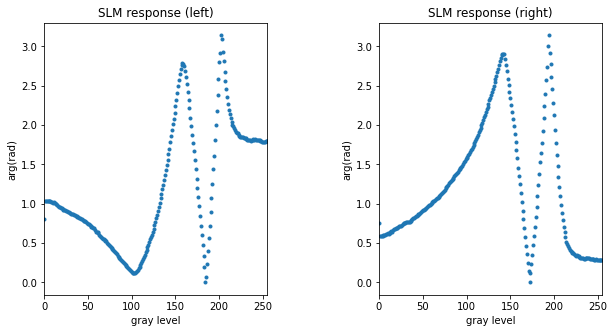

In [47]:
l = l1
phl = arccos(p1)
phr = arccos(p2)

fig,ax = plt.subplots(1,2,figsize=(10,5))
plt.subplots_adjust(wspace = 0.5)

ax[0].plot(l,phl,'.')
ax[0].set_xlim(0,255)
ax[0].set_title('SLM response (left)')
ax[0].set(xlabel = 'gray level', ylabel = r'arg(rad)')

ax[1].plot(l,phr,'.')
ax[1].set_xlim(0,255)
ax[1].set_title('SLM response (right)')
ax[1].set(xlabel = 'gray level', ylabel = r'arg(rad)')

# Unwrap the phase --> pick one of the two pistoning measurements

Whole SLM phase drive right pistoning =  11.469128538290724 rad,  1.8253684998252928  cycles
Whole SLM phase drive left pistoning =  11.187833548823315 rad,  1.7805990117845722  cycles


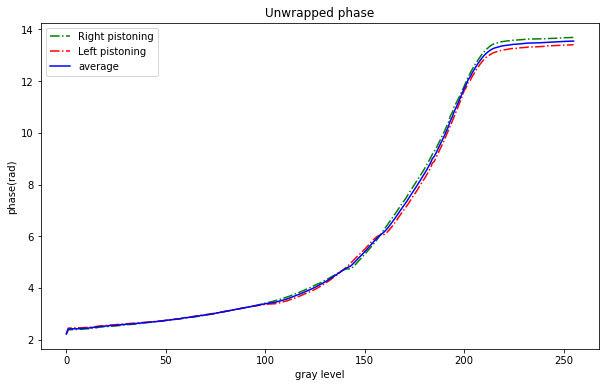

In [63]:
def unwrap_phase(phi):
    uwph = zeros(phi.shape[0]) #my fresh new unwrapped phase vector
    Aph = phi[1::]-phi[0:-1] #Get the gradient --> using left side
    uwph[0] = sel_ph[0] #Assign first element

    for idx,step in enumerate(abs(Aph)):
        uwph[idx+1] = uwph[idx] + step
        
    return(uwph)

uwph_r = unwrap_phase(phr)
uwph_l = unwrap_phase(phl)
uwph_av = (uwph_r + uwph_l) /2

fig,ax = plt.subplots(1,1,figsize=(10,6))
ax.plot(l,uwph_r,'-.',color='green',label = 'Right pistoning')
ax.plot(l,uwph_l,'-.',color='red',label = 'Left pistoning')
ax.plot(l,uwph_av,color='blue',label = 'average')

ax.set_title('Unwrapped phase')
ax.set(xlabel = 'gray level', ylabel = r'phase(rad)')
print('Whole SLM phase drive right pistoning = ', uwph_r.max() - uwph_r.min(), 'rad, ', (uwph_r.max() - uwph_r.min())/(2*pi), ' cycles')
print('Whole SLM phase drive left pistoning = ', uwph_l.max() - uwph_l.min(), 'rad, ', (uwph_l.max() - uwph_l.min())/(2*pi), ' cycles')
legend()
uwph = uwph_av #uwph_l

# Translating unwraped phase to SLM language (Voltage levels!!)

Array position Start:  161 Nearest value:  0.9968450453270719
Array position Stop:  206 Nearest value:  2.000375951027386
min Voltage level:  1292.4196078431373 --> 0pi
max Voltage level:  1653.6549019607844  --> 2pi


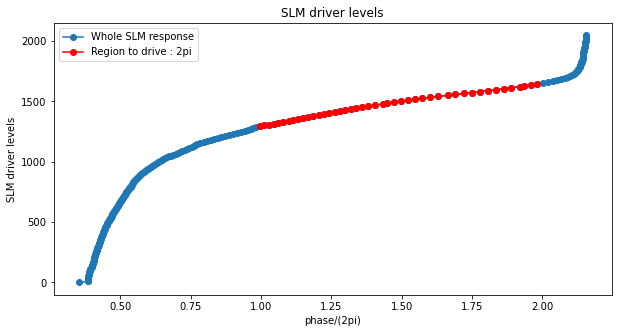

In [66]:
# SLM has 2047 levels (11 bits)
# Display just 256 levels: default lineal LUT maps 0 to 0 up 2047 to 256 using whole voltage range of the SLM driver (256 values between 0 and 2047)
#     --> NOW we just want to map all those 256 levels in a region that give us a phsae shift between 0 and 2pi
voltageDriver = linspace(0,2047,256)
#Normalize ph to multiples of 2pi
uwph_w = uwph / (2*pi)
fig,ax = plt.subplots(1,1,figsize=(10,5))
plot(uwph_w,voltageDriver,'-o',label='Whole SLM response')
ax.set_title('SLM driver levels')
ax.set(xlabel = r'phase/(2pi)', ylabel = 'SLM driver levels')
#Selet region : from 0.6 t0 1.6
region = zeros(voltageDriver.shape[0])
regin_startValue = 1
regin_stopValue = 2
diff_start = abs(uwph_w - regin_startValue)
diff_stop = abs(uwph_w - regin_stopValue)
value_start = diff_start.argmin()
value_stop = diff_stop.argmin()
print('Array position Start: ', value_start, 'Nearest value: ', uwph_w[value_start] )
print('Array position Stop: ', value_stop, 'Nearest value: ', uwph_w[value_stop] )
plot(uwph_w[value_start:value_stop],voltageDriver[value_start:value_stop],'-o',color='red',label='Region to drive : 2pi')
legend()
print('min Voltage level: ', voltageDriver[value_start], '--> 0pi' )
print('max Voltage level: ', voltageDriver[value_stop], ' --> 2pi')



# Fit experimental data to a spline( ph(V) ) then invert ( V(ph) )

[Text(0.5, 0, 'Voltage level'), Text(0, 0.5, 'cycles')]

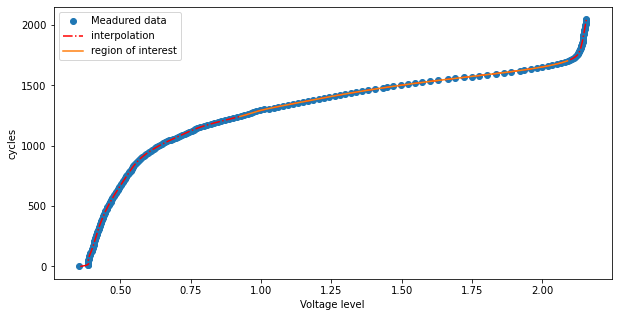

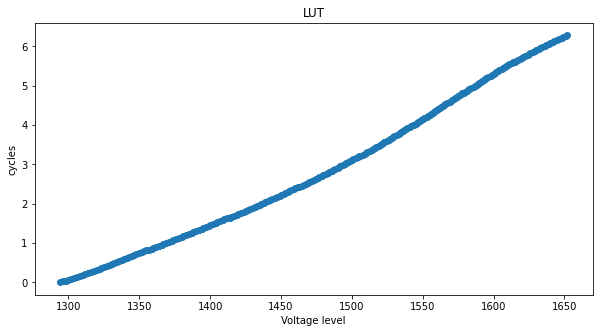

In [67]:
#Fit to the spline --> Phase function that depend on the voltage
spl = UnivariateSpline(voltageDriver,uwph_w, k = 3)
spl.set_smoothing_factor(0.0005)
phase = spl(voltageDriver)

fig,ax = plt.subplots(1,1,figsize=(10,5))
plot(uwph_w,voltageDriver,'o',label = 'Meadured data')
plot(phase,voltageDriver,'-.',color = 'red',label = 'interpolation')
ax.set(xlabel = 'Voltage level', ylabel = 'cycles')
legend()

#Let's avoid to inverd weird regions --> invert just region of interest + some more samples --> Voltage function that depend on ph
voltage_region = linspace(voltageDriver[value_start]-50,voltageDriver[value_stop]+50,256) #Select some region around
phase_region = spl(voltage_region)#Get the phase
spl_vol = UnivariateSpline(phase_region,voltage_region, k = 3) #Fit to the inverted spline
spl_vol.set_smoothing_factor(0)
plot(phase_region,spl_vol(phase_region),label='region of interest') #What I am gonna to invert
legend()

#NOW --> Select the 0 to 2pi region in this case 1 to 2
phase_range = linspace(1,2,256) #Accurate region to produce 0 to 2pi shift
LUT_voltage = around(spl_vol(phase_range)).astype(int) #THE LUT VOLTAGES!!!!!
fig,ax = plt.subplots(1,1,figsize=(10,5))

#PLOT THE ACCURATE SLM REGION TO PRODUCE 2pi shift
#Just for visual pourposes, scale the region in this case 0.6 = 0 / 1.6 = 2pi
phase_range_norm = phase_range - phase_range.min()
phase_range_norm = phase_range_norm/phase_range_norm.max() *2*pi
plot(LUT_voltage,phase_range_norm,'-o')
title('LUT')
ax.set(xlabel = 'Voltage level', ylabel = 'cycles')





In [68]:
where(phase_range_norm > pi)

(array([128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140,
        141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153,
        154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166,
        167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179,
        180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192,
        193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205,
        206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218,
        219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231,
        232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244,
        245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255], dtype=int64),)

# Check voltages if you want: if you get linear steps, probably you are doing something wrong or SLM is soooooo GOOD!

[1294 1296 1298 1300 1302 1304 1306 1308 1310 1312 1314 1316 1318 1320
 1322 1323 1325 1327 1329 1331 1332 1334 1336 1338 1339 1341 1343 1345
 1346 1348 1350 1352 1353 1355 1357 1359 1360 1362 1364 1366 1367 1369
 1371 1373 1374 1376 1378 1380 1381 1383 1385 1387 1388 1390 1392 1394
 1395 1397 1399 1400 1402 1404 1405 1407 1409 1410 1412 1414 1415 1417
 1419 1420 1422 1424 1425 1427 1428 1430 1432 1433 1435 1436 1438 1439
 1441 1442 1444 1446 1447 1449 1450 1452 1453 1455 1456 1457 1459 1460
 1462 1463 1465 1466 1468 1469 1470 1472 1473 1475 1476 1477 1479 1480
 1482 1483 1484 1486 1487 1488 1490 1491 1492 1494 1495 1496 1497 1499
 1500 1501 1503 1504 1505 1506 1508 1509 1510 1511 1513 1514 1515 1516
 1517 1519 1520 1521 1522 1523 1525 1526 1527 1528 1529 1530 1532 1533
 1534 1535 1536 1537 1538 1539 1541 1542 1543 1544 1545 1546 1547 1548
 1549 1550 1551 1553 1554 1555 1556 1557 1558 1559 1560 1561 1562 1563
 1564 1565 1566 1567 1569 1570 1571 1572 1573 1574 1575 1576 1577 1578
 1579 

(256,)

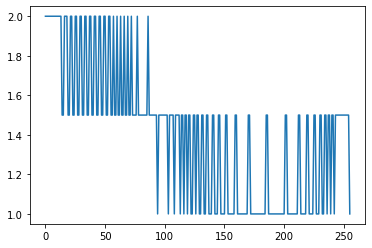

In [69]:
plot(gradient(LUT_voltage))
print(LUT_voltage)
LUT_voltage.shape

# Save the LUT!!

In [70]:
np.savetxt('SLM_002_AR_1300nm_6,2V_14_average.blt', np.transpose(LUT_voltage), fmt='%.18g')